## 12.06 目标检测数据集


### 环境配置


In [3]:
import os, sys
sys.path.insert(0, "..")
os.environ["TILE_FWK_DEVICE_ID"] = "1"
import warnings
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    import pypto
    import torch
    import torch_npu
    import torchvision
    from torch import nn
    from torch.nn import functional as F
    from src.D2LFunction import *

import logging
# pypto 导入会把根 logger 调到 DEBUG，压回 WARNING 避免刷屏
logging.getLogger().setLevel(logging.WARNING)
logging.getLogger("matplotlib").setLevel(logging.WARNING)
logging.getLogger("PIL").setLevel(logging.WARNING)

device_id = int(os.environ["TILE_FWK_DEVICE_ID"])
torch.npu.set_device(device_id)
device = f"npu:{device_id}"


---


### 练习 12.6.1

**题目：** 在香蕉检测数据集中演示其他带有真实边界框的图像。它们在边界框和目标方面有什么不同？

**解答：**

&emsp;&emsp;不同图像中香蕉的边界框在宽高比、缩放比和位置上有所不同；目标本身（香蕉）的旋转角度、大小、位置以及光照等也各不相同。

以下使用 `torch` 编程进行验证：


In [6]:
import pandas as pd

# 香蕉检测数据集读取（与主 notebook 12.6 节一致，D2LFunction 未内置）
DATA_HUB['banana-detection'] = (DATA_URL + 'banana-detection.zip',
                                '5de26c58fce8bcd781d198e0d4a8d2236d5d32ee')

def read_data_bananas(is_train=True):
    data_dir = download_extract('banana-detection')
    csv_fname = os.path.join(data_dir, 'bananas_train' if is_train
                             else 'bananas_val', 'label.csv')
    csv_data = pd.read_csv(csv_fname)
    csv_data = csv_data.set_index('img_name')
    images, targets = [], []
    for img_name, target in csv_data.iterrows():
        images.append(torchvision.io.read_image(
            os.path.join(data_dir, 'bananas_train' if is_train else
                         'bananas_val', 'images', f'{img_name}')))
        targets.append(list(target))
    return images, torch.tensor(targets).unsqueeze(1) / 256

class BananasDataset(torch.utils.data.Dataset):
    def __init__(self, is_train):
        self.features, self.labels = read_data_bananas(is_train)
        print('read ' + str(len(self.features)) + (f' training examples' if
              is_train else f' validation examples'))

    def __getitem__(self, idx):
        return (self.features[idx].float(), self.labels[idx])

    def __len__(self):
        return len(self.features)

def load_data_bananas(batch_size):
    train_iter = torch.utils.data.DataLoader(BananasDataset(is_train=True),
                                             batch_size, shuffle=True)
    val_iter = torch.utils.data.DataLoader(BananasDataset(is_train=False),
                                           batch_size)
    return train_iter, val_iter

正在从http://d2l-data.s3-accelerate.amazonaws.com/banana-detection.zip下载../data/banana-detection.zip...
read 1000 training examples
正在从http://d2l-data.s3-accelerate.amazonaws.com/banana-detection.zip下载../data/banana-detection.zip...
read 100 validation examples
图像形状: torch.Size([32, 3, 256, 256]) 标签形状: torch.Size([32, 1, 5])


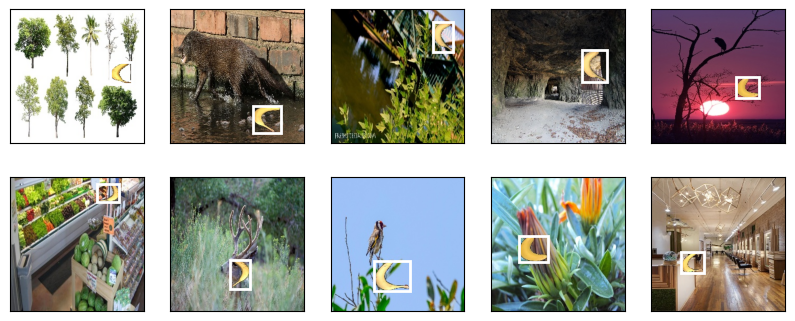

In [7]:
batch_size, edge_size = 32, 256
train_iter, _ = load_data_bananas(batch_size)
batch = next(iter(train_iter))
print('图像形状:', batch[0].shape, '标签形状:', batch[1].shape)

# 展示另外10张（第11~20张）带真实边界框的香蕉图像
imgs = (batch[0][11:21].permute(0, 2, 3, 1)) / 255
axes = show_images(imgs, 2, 5, scale=2)
for ax, label in zip(axes, batch[1][11:21]):
    show_bboxes(ax, [label[0][1:5] * edge_size], colors=['w']);

&emsp;&emsp;可以看到，不同图像中香蕉的大小、朝向、位置与光照差异明显，对应的边界框也随之改变：横放的香蕉边界框宽大于高，竖放的香蕉边界框高大于宽。

使用 `PyPTO` 编程进行验证（12.4 节已把锚框生成 `multibox_prior` 与交并比 `box_iou` 下沉为 PyPTO kernel，这里在香蕉检测数据上串起这两个算子：为一张香蕉图生成锚框，再计算每个锚框与真实边界框的 IoU——这是 `assign_anchor_to_bbox`（按 IoU 贪心分配锚框）的第一步，也是练习 12.6.2 提到的"目标检测中边界框必须随图像一起变换"的数值基础）：

In [10]:
# PyPTO 验证：香蕉图上生成锚框 + 计算与真实框的 IoU（src/PyPTOAnchor.py kernel 下沉）
from src.PyPTOAnchor import multibox_prior as mb_prior_pypto
from src.PyPTOAnchor import box_iou as box_iou_pypto
from src.PyPTOAnchor import box_center_to_corner as bctc_pypto

# 用验证集第 1 张图（顺序固定，结果可复现；训练集 DataLoader 打乱顺序会改变演示数值）
val_images, val_labels = read_data_bananas(is_train=False)
X_banana = val_images[0].float().unsqueeze(0).contiguous().to(device)
                          # (1,3,256,256): read_image 返回非连续 uint8，需 contiguous()
anchors_pt = mb_prior_pypto(X_banana, sizes=[0.05, 0.1], ratios=[1, 2, 0.5])
print('PyPTO 锚框数量:', anchors_pt.shape[1])  # 256*256 像素 x bpp=4

gt_banana = val_labels[0, 0, 1:].float().to(device)  # 真实框 (cx, cy, w, h)
gt_corner = bctc_pypto(gt_banana.unsqueeze(0))     # PyPTO kernel 转角点格式
iou_pt = box_iou_pypto(anchors_pt[0], gt_corner)   # PyPTO kernel IoU
print('PyPTO IoU 矩阵形状:', tuple(iou_pt.shape))
print('与真实框 IoU>0.1 的锚框数:', int((iou_pt[:, 0] > 0.1).sum()),
      '，最大 IoU:', f'{iou_pt[:, 0].max().item():.4f}')


正在从http://d2l-data.s3-accelerate.amazonaws.com/banana-detection.zip下载../data/banana-detection.zip...
PyPTO 锚框数量: 262144
PyPTO IoU 矩阵形状: (262144, 1)
与真实框 IoU>0.1 的锚框数: 0 ，最大 IoU: 0.0243


&emsp;&emsp;密集锚框中绝大多数与真实边界框的 IoU 很小（< 0.1），这与 12.4 节"先按 IoU 把真实框分配给最近的锚框"的贪心策略一致：IoU 匹配是目标检测回归训练的基础。练习 12.6.2 提到的随机裁剪增广会同时改变图像与边界框坐标，若裁剪只切到目标的一小部分，其与锚框的 IoU 将骤降，导致该目标无法匹配任何锚框——这正是目标检测与图像分类增广的关键差异。

---


### 练习 12.6.2

**题目：** 假设我们想要将数据增强（例如随机裁剪）应用于目标检测。它与图像分类中的有什么不同？提示：如果裁剪的图像只包含物体的一小部分会怎样？

**解答：**

&emsp;&emsp;当将数据增强应用于目标检测时，与图像分类相比存在以下重要区别：

1. **目标完整性**：随机裁剪可能只包含物体的一小部分，导致目标部分遗漏或缺失，算法无法准确定位和识别不完整的目标；
2. **边界框更新**：裁剪等变换改变了目标在图像中的位置和大小，必须同步更新边界框坐标，使标签与图像保持一致（分类任务只需变换图像、类别标签不变）；
3. **多对象处理**：目标检测通常涉及多个对象，增强操作需要保证所有目标的完整性与可见性，避免遮挡或分割目标。

&emsp;&emsp;因此在目标检测中，数据增强需要与边界框变换协同设计，以确保模型能够应对多尺度、多目标和各种变化条件。

---
## 参考答案来源
参考答案和 PyTorch 代码实现来源：[https://datawhalechina.github.io/d2l-ai-solutions-manual/#/](https://datawhalechina.github.io/d2l-ai-solutions-manual/#/)
